此测试文件是帮助我评估tri方法是否有效

流程：
1. 从‘Merged_tasks’中提取储层的超参数以及它们对应的flag
2. 将超参数们变成一个dict
3. 从dict中依次提取超惨数组，执行'softgate'来获取对应的计算flag
4. 将计算flag与真正的flag进行比较。看看正确率多少

In [1]:
# import necessary libraries
import os
import torch 
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt
import tqdm as tqdm
import pickle
from pathlib import Path
CANDIDATES = [
    
    Path(r"C:\Users\tom\Desktop\Repository"),
    Path(r"C:\Users\Chen\Desktop\Repository"),
    Path(r"/Users/vvvp./Desktop"),
]
searchpaths = [p for p in CANDIDATES if p.exists()]

#tuple of repos
repos = ('machine_learning_library',)

import sys
import os
# In Jupyter notebooks, __file__ is not defined. Use the current working directory instead.
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import repo_tools
repo_tools.repos_path_finder(searchpaths, repos)
from spnc import spnc_anisotropy
import spnc_ml as ml
from deterministic_mask import fixed_seed_mask, max_sequences_mask

from single_node_res import single_node_reservoir
import ridge_regression as RR
from linear_layer import *
from mask import binary_mask
from utility import *
from NARMA10 import NARMA10
from datasets.load_TI46_digits import *
import datasets.load_TI46 as TI46
from sklearn.metrics import classification_report
from formal_Parameter_Dynamics_Preformance import *


In [2]:
# 构建储层对象
class ReservoirParams:
    def __init__(self, **kwargs):
            # Reservoir parameters 
            self.h = 0.4
            self.theta_H = 90
            self.k_s_0 = 0
            self.phi = 45
            self.beta_prime = 35.13826524755751

            # Network parameters 
            self.Nvirt = 50
            self.m0 = 0.005288612874870094
            self.bias = True
            self.Nwarmup = 0
            self.verbose_repr = False

            self.params = {
                'theta': 0.34142235979698393,
                'gamma': 0.069274461903986,
                'delay_feedback': 0,
                'Nvirt': self.Nvirt,
                'length_warmup': self.Nwarmup,
                'warmup_sample': self.Nwarmup * self.Nvirt,
                'voltage_noise': False,
                'seed_voltage_noise': 1234,
                'delta_V': 0.1,
                'johnson_noise': False,
                'seed_johnson_noise': 1234,
                'mean_johnson_noise': 0.0000,
                'std_johnson_noise': 0.00001,
                'thermal_noise': False,
                'seed_thermal_noise': 1234,
                'lambda_ou': 1.0,
                'sigma_ou': 0.1
        }

            for key in ['h', 'theta_H', 'k_s_0', 'phi', 'beta_prime', 'Nvirt', 'm0', 'bias', 'Nwarmup']:
                if key in kwargs:
                    setattr(self, key, kwargs[key])

            
            if 'params' in kwargs and isinstance(kwargs['params'], dict):
                self.params.update(kwargs['params'])

    
    def update_params(self, **kwargs):
        for key, value in kwargs.items():
            if hasattr(self, key):
                setattr(self, key, value)
            if key in self.params:
                self.params[key] = value
            if not hasattr(self, key) and key not in self.params:
                raise AttributeError(f"ReservoirParams has no attribute or param key '{key}'")
            
    def print_params(self, verbose=False):
        if not verbose:
            print(f"ReservoirParams(h={self.h}, beta_prime={self.beta_prime}, Nvirt={self.Nvirt})")
        else:
            print(f"ReservoirParams detailed info:")
            print(f"  h = {self.h}")
            print(f"  theta_H = {self.theta_H}")
            print(f"  k_s_0 = {self.k_s_0}")
            print(f"  phi = {self.phi}")
            print(f"  beta_prime = {self.beta_prime}")
            print(f"  Nvirt = {self.Nvirt}")
            print(f"  m0 = {self.m0}")
            print(f"  bias = {self.bias}")
            print("  params dictionary:")
            for k, v in self.params.items():
                print(f"    {k}: {v}")

In [3]:
# 三角波输入
T = 1000; cycles = 4
t = np.linspace(0, 1, T)
tri = 2*np.abs(2*(t*cycles % 1)-1)-1


In [ ]:
# 筛选器
def filter(u,y,period):
    
    y = np.ravel(np.asarray(y))
    u = np.ravel(np.asarray(u))
    assert len(y) == len(u)

    # Sat
    ymin, ymax = y.min(), y.max(); R = max(1e-12, ymax - ymin)
    Sat = np.mean((y <= ymin + 0.1*R) | (y >= ymax - 0.1*R))
    # Drift
    t = np.arange(len(y))
    Drift = 0.0 if y.std() == 0 else float(abs(np.corrcoef(t, y)[0,1]))
    # Lag
    y0 = y - y.mean(); u0 = u - u.mean()
    L = np.argmax(np.correlate(y0, u0, mode='full')) - (len(y)-1)
    LagRatio = abs(L) / float(period)
    # THD（简单版；如需更准可按前文加入去趋势/窗/零填充）
    Yf = np.fft.rfft(y0)
    freqs = np.fft.rfftfreq(len(y), d=1)
    f0 = 1.0/float(period)
    k1 = np.argmin(abs(freqs - f0))
    A1 = abs(Yf[k1]); Ak = np.abs(Yf); 
    Ak[[0, k1]] = 0
    THD = float(np.linalg.norm(Ak) / (A1 + 1e-12))

    # 轻门槛
    hard_pass = (Drift<=0.60) and (THD<=0.80)              # 移除 Lag 的下限
    
    # 加权分
    z_sat   = max(0.0, 1.0 - Sat)
    z_drift = max(0.0, 1.0 - Drift)
    z_lag   = max(0.0, 1.0 - abs(LagRatio - 0.2)/0.2)
    z_thd   = max(0.0, 1.0 - THD/0.8)

    score = 0.35*z_sat + 0.25*z_drift + 0.20*z_lag + 0.20*z_thd
    pass_flag = hard_pass and (score >= 0.55)

    info = dict(Sat=Sat, Drift=Drift, LagRatio=LagRatio, THD=THD,
                z_sat=z_sat, z_drift=z_drift, z_lag=z_lag, z_thd=z_thd)
    return pass_flag, score, info

In [5]:
# 储层
def softgate(tri, augment_dict, plot = False):
    """
    运行SPNC实验的封装函数
    
    参数:
    tri: 输入信号
    augment_dict: 包含augment参数的字典，包含以下参数:
                 - trial: 试验编号
                 - m0: ReservoirParams参数m0 
                 - beta_prime: ReservoirParams参数beta_prime 
                 - theta: spn参数theta 
                 - gamma: spn参数gamma 
    plot: 是否绘图 (默认False)
    
    返回:
    result: 包含pass_flag, score, info的字典
    """
    
    # 从augment_dict中提取参数值
    trial = augment_dict.get('trial', 0)
    m0 = augment_dict.get('m0', 0.008)
    beta_prime = augment_dict.get('beta_prime', 20.0)
    theta = augment_dict.get('theta', 0.145090117811982)
    gamma = augment_dict.get('gamma', 0.09907866306038172)
    
    # 创建spn对象
    spn = spnc_anisotropy(0.4,90,0,45,beta_prime,restart=True)

    # 创建ReservoirParams对象
    params = ReservoirParams(
        h=0.4, m0=m0, Nvirt=1, beta_prime=beta_prime,
        params={'theta': theta, 'gamma': gamma, 'Nvirt': 1}
    )

    # 生成信号
    transform = spn.gen_signal_slow_delayed_feedback
    S = RunSpnc(tri.reshape(-1, 1), 1, 1, params.Nvirt, params.m0, transform, params.params, fixed_mask=True, seed_mask=1234)

    # 计算结果
    result = {}
    result['pass_flag'], result['score'], result['info'] = filter(tri, S, 250)

    # 判定是否是quiet
    if plot:
        plt.figure(figsize=(10, 5))
        plt.plot(S)
        plt.title(f'Trial {trial}')
        plt.xlabel("Time")
        plt.ylabel("Signal")
        plt.show()

    return result

In [6]:
# 从'C:\Users\Chen\Desktop\Repository\spnc_taskindependent_metrics\ParetoFront_CQandMC\Merged_Results.csv'中提取超参数
import pandas as pd
df = pd.read_csv(r'C:\Users\Chen\Desktop\Repository\spnc_taskindependent_metrics\ParetoFront_CQandMC\Merged_Results.csv')

# 将DataFrame行转换为softgate函数所需的augment_dict格式
def df_to_augment_dict(row):
    """
    将DataFrame的一行转换为softgate函数所需的augment_dict格式
    
    参数:
    row: DataFrame的一行（pandas Series）
    
    返回:
    augment_dict: 包含所需参数的字典
    """
    augment_dict = {
        'trial': row['trial_number'],
        'm0': row['m0'],
        'beta_prime': row['beta_prime'],
        'theta': row['theta'],
        'gamma': row['gamma']
    }
    return augment_dict

# 示例：转换第一行数据
first_row_dict = df_to_augment_dict(df.iloc[0])
print("第一行转换后的augment_dict格式:")
print(first_row_dict)

第一行转换后的augment_dict格式:
{'trial': np.float64(203.0), 'm0': np.float64(0.008), 'beta_prime': np.float64(43.45746905), 'theta': np.float64(0.6), 'gamma': np.float64(0.5)}


In [16]:
# 完整测试示例：比较计算flag与真实flag
def test_softgate_accuracy():
    """
    测试softgate函数的准确性：
    1. 从df中提取每行的超参数
    2. 使用softgate函数计算predicted flag
    3. 与真实flag进行比较
    """
    
    correct_predictions = 0
    total_predictions = 0
    
    results = []
    
    for idx, row in df.iterrows():
        # 转换为augment_dict格式
        augment_dict = df_to_augment_dict(row)
        
        # 获取真实flag
        true_flag = row['flag']
        
        # 使用softgate函数计算predicted flag
        result = softgate(tri, augment_dict, plot=False)
        predicted_flag = 1 if result['pass_flag'] else 0
        
        # 记录结果
        is_correct = (predicted_flag == true_flag)
        results.append({
            'trial': augment_dict['trial'],
            'true_flag': true_flag,
            'predicted_flag': predicted_flag,
            'score': result['score'],
            'correct': is_correct
        })
        
        if is_correct:
            correct_predictions += 1
        total_predictions += 1
        
        print(f"Trial {augment_dict['trial']}: True={true_flag}, Predicted={predicted_flag}, Score={result['score']:.3f}, {'✓' if is_correct else '✗'}")
    
    accuracy = correct_predictions / total_predictions if total_predictions > 0 else 0
    print(f"\n总体准确率: {accuracy:.3f} ({correct_predictions}/{total_predictions})")
    
    return results

# 如果要运行完整测试，取消注释下面这行
test_results = test_softgate_accuracy()

Trial 203.0: True=0.0, Predicted=0, Score=0.230, ✓
Trial 121.0: True=0.0, Predicted=0, Score=0.117, ✓
Trial 263.0: True=0.0, Predicted=1, Score=0.735, ✗
Trial 157.0: True=0.0, Predicted=0, Score=0.137, ✓
Trial 94.0: True=0.0, Predicted=0, Score=0.131, ✓
Trial 205.0: True=0.0, Predicted=1, Score=0.700, ✗
Trial 277.0: True=0.0, Predicted=0, Score=0.118, ✓
Trial 228.0: True=0.0, Predicted=0, Score=0.100, ✓
Trial 155.0: True=0.0, Predicted=1, Score=0.714, ✗
Trial 301.0: True=0.0, Predicted=0, Score=0.114, ✓
Trial 26.0: True=1.0, Predicted=1, Score=0.741, ✓
Trial 41.0: True=1.0, Predicted=1, Score=0.694, ✓
Trial 38.0: True=1.0, Predicted=1, Score=0.696, ✓
Trial 89.0: True=1.0, Predicted=1, Score=0.702, ✓
Trial 116.0: True=1.0, Predicted=1, Score=0.783, ✓
Trial 290.0: True=1.0, Predicted=1, Score=0.711, ✓
Trial 283.0: True=1.0, Predicted=1, Score=0.714, ✓
Trial 288.0: True=1.0, Predicted=1, Score=0.718, ✓
Trial 280.0: True=1.0, Predicted=1, Score=0.738, ✓
Trial 240.0: True=1.0, Predicted=1, 

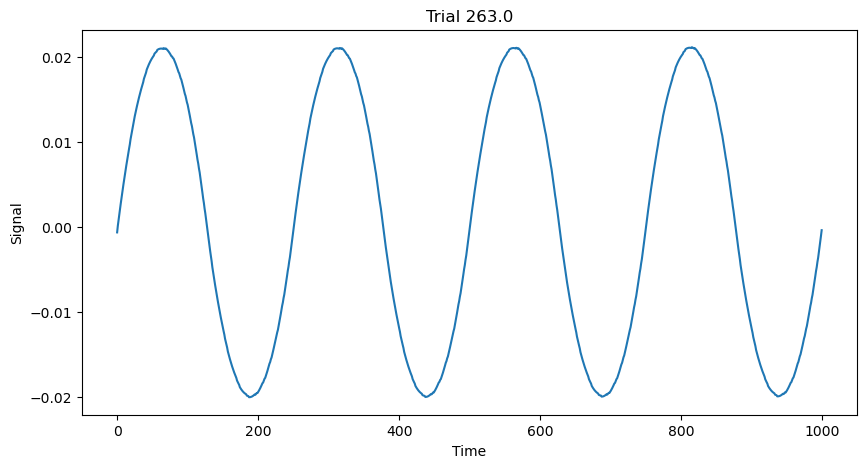

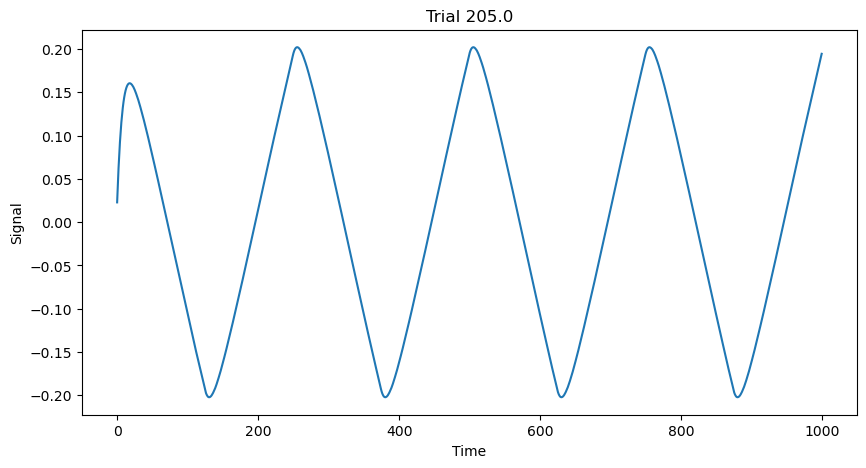

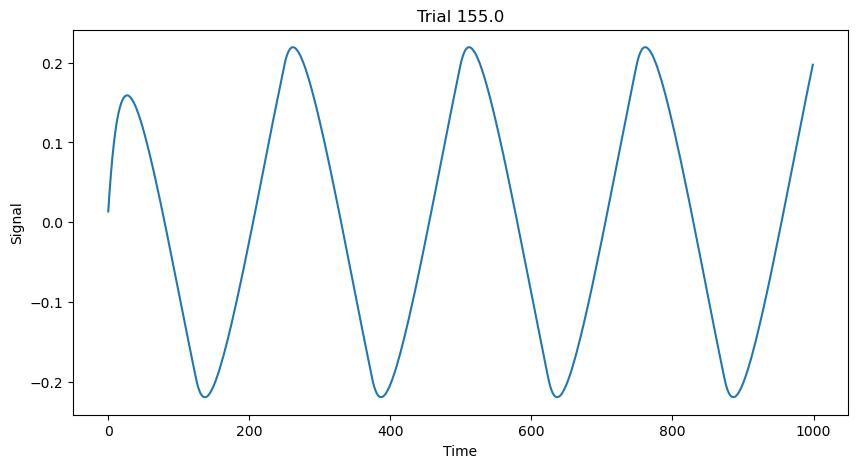

In [17]:
# 单独看看trial263，205，155的图像

# 单独提取trial263的超参数
augment_263 = df_to_augment_dict(df.iloc[2])
augment_205 = df_to_augment_dict(df.iloc[5])
augment_155 = df_to_augment_dict(df.iloc[8])

# 执行softgate
result = softgate(tri, augment_263, plot=True)
result = softgate(tri, augment_205, plot=True)
result = softgate(tri, augment_155, plot=True)

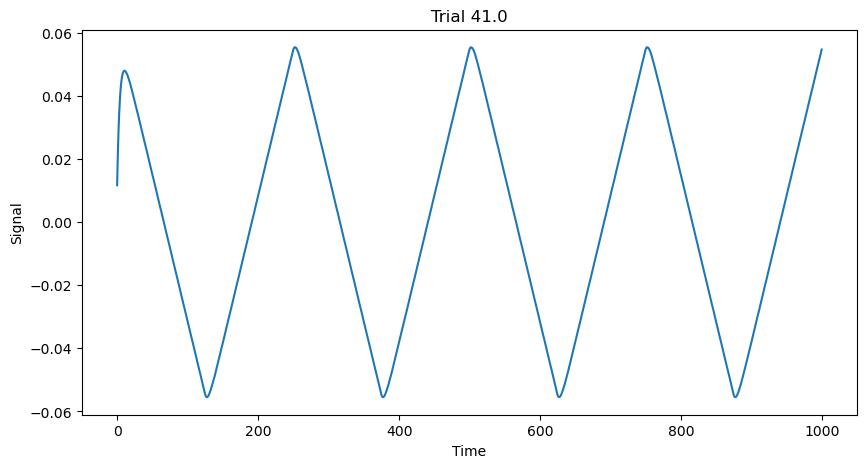

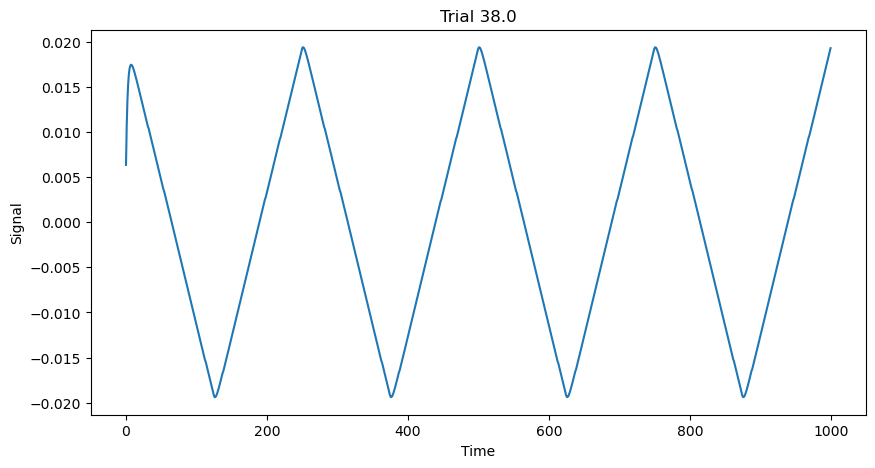

{'Sat': np.float64(0.219), 'Drift': 0.006115181049374131, 'LagRatio': np.float64(0.004), 'THD': 0.12064869738446805, 'z_sat': np.float64(0.781), 'z_drift': 0.9938848189506259, 'z_lag': np.float64(0.020000000000000018), 'z_thd': 0.849189128269415}


In [18]:
# trial41和38
augment_41 = df_to_augment_dict(df.iloc[11])
augment_38 = df_to_augment_dict(df.iloc[12])


# 执行softgate
result = softgate(tri, augment_41, plot=True)
result = softgate(tri, augment_38, plot=True)

print(result['info'])


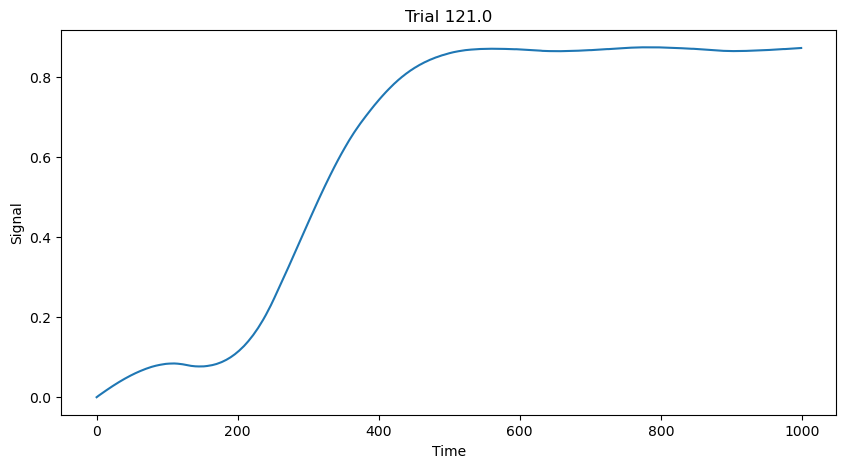

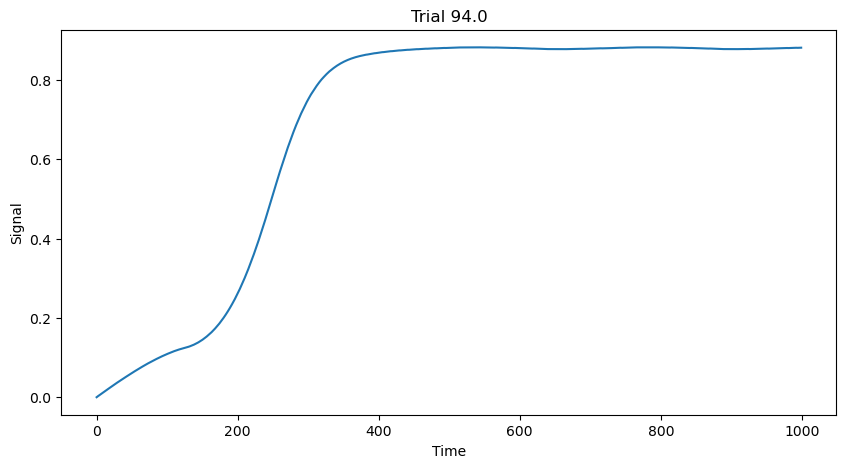

In [13]:
# 看看没有过的trial
augment_121 = df_to_augment_dict(df.iloc[1])
augment_94 = df_to_augment_dict(df.iloc[4])


# 执行softgate
result = softgate(tri, augment_121, plot=True)
result = softgate(tri, augment_94, plot=True)


接下来让我们选择‘result_dict_beta50’作为测试集来检验下

In [23]:
# 从'C:\Users\Chen\Desktop\Repository\spnc_taskindependent_metrics\ParetoFront_CQandMC\Merged_Results.csv'中提取超参数
import pandas as pd
df = pd.read_csv(r'C:\Users\Chen\Desktop\Repository\spnc_taskindependent_metrics\ParetoFront_CQandMC\Test_Results.csv')

# 将DataFrame行转换为softgate函数所需的augment_dict格式
def df_to_augment_dict(row):
    """
    将DataFrame的一行转换为softgate函数所需的augment_dict格式
    
    参数:
    row: DataFrame的一行（pandas Series）
    
    返回:
    augment_dict: 包含所需参数的字典
    """
    augment_dict = {
        'trial': row['trial_number'],
        'm0': row['m0'],
        'beta_prime': row['beta_prime'],
        'theta': row['theta'],
        'gamma': row['gamma']
    }
    return augment_dict

# 示例：转换第一行数据
first_row_dict = df_to_augment_dict(df.iloc[0])
print("第一行转换后的augment_dict格式:")
print(first_row_dict)

第一行转换后的augment_dict格式:
{'trial': np.float64(0.0), 'm0': np.float64(0.173894996), 'beta_prime': np.float64(50.0), 'theta': np.float64(0.2), 'gamma': np.float64(0.094318864)}


In [24]:
# 完整测试示例：比较计算flag与真实flag
def test_softgate_accuracy():
    """
    测试softgate函数的准确性：
    1. 从df中提取每行的超参数
    2. 使用softgate函数计算predicted flag
    3. 与真实flag进行比较
    """
    
    correct_predictions = 0
    total_predictions = 0
    
    results = []
    
    for idx, row in df.iterrows():
        # 转换为augment_dict格式
        augment_dict = df_to_augment_dict(row)
        
        # 获取真实flag
        true_flag = row['flag']
        
        # 使用softgate函数计算predicted flag
        result = softgate(tri, augment_dict, plot=False)
        predicted_flag = 1 if result['pass_flag'] else 0
        
        # 记录结果
        is_correct = (predicted_flag == true_flag)
        results.append({
            'trial': augment_dict['trial'],
            'true_flag': true_flag,
            'predicted_flag': predicted_flag,
            'score': result['score'],
            'correct': is_correct
        })
        
        if is_correct:
            correct_predictions += 1
        total_predictions += 1
        
        print(f"Trial {augment_dict['trial']}: True={true_flag}, Predicted={predicted_flag}, Score={result['score']:.3f}, {'✓' if is_correct else '✗'}")
    
    accuracy = correct_predictions / total_predictions if total_predictions > 0 else 0
    print(f"\n总体准确率: {accuracy:.3f} ({correct_predictions}/{total_predictions})")
    
    return results

# 如果要运行完整测试，取消注释下面这行
test_results = test_softgate_accuracy()

Trial 0.0: True=0.0, Predicted=0, Score=0.437, ✓
Trial 1.0: True=0.0, Predicted=0, Score=0.470, ✓
Trial 2.0: True=0.0, Predicted=0, Score=0.434, ✓
Trial 3.0: True=0.0, Predicted=0, Score=0.528, ✓
Trial 4.0: True=0.0, Predicted=0, Score=0.453, ✓
Trial 5.0: True=0.0, Predicted=0, Score=0.501, ✓
Trial 6.0: True=0.0, Predicted=0, Score=0.463, ✓
Trial 7.0: True=0.0, Predicted=0, Score=0.472, ✓
Trial 8.0: True=0.0, Predicted=0, Score=0.448, ✓
Trial 9.0: True=0.0, Predicted=0, Score=0.440, ✓
Trial 10.0: True=0.0, Predicted=0, Score=0.473, ✓
Trial 11.0: True=0.0, Predicted=0, Score=0.475, ✓
Trial 12.0: True=0.0, Predicted=0, Score=0.440, ✓
Trial 13.0: True=0.0, Predicted=0, Score=0.480, ✓
Trial 14.0: True=0.0, Predicted=0, Score=0.449, ✓
Trial 15.0: True=0.0, Predicted=0, Score=0.454, ✓
Trial 16.0: True=0.0, Predicted=0, Score=0.442, ✓
Trial 17.0: True=0.0, Predicted=0, Score=0.453, ✓
Trial 18.0: True=0.0, Predicted=0, Score=0.459, ✓
Trial 19.0: True=0.0, Predicted=0, Score=0.441, ✓
Trial 20.0